# Defect Subtype Classification

**Purpose.** Explain the model that names the defect after anomaly detection has already decided that a defect exists.

**Expected result.** A category-by-category classifier inventory, saved validation metrics, a confusion matrix, and live predictions from each supported classifier runtime.

**Platform connection.** Subtype classification never decides Good versus Defective. It runs only for a detected anomaly and returns labels such as `broken_large`, `poke_insulation`, or `crack`.

## Classifier priority used at inference

```text
1. Fine-tuned ResNet18 ONNX classifier, when available
2. Compact NumPy forest, when available
3. Category-specific scikit-learn classifier (.pkl)
```

The detector mask is used to form an object/defect-focused crop. Depending on the trained artifact, features combine ResNet18 embeddings with texture, gradient, color, mask-shape, or ROI statistics. If the anomaly detector says “Defective” but the subtype classifier predicts “good”, the pipeline reports `unknown_defect` rather than inventing a subtype.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from ml.model_registry import SUPPORTED_CATEGORIES, category_model_spec

classifier_rows = []
for category in SUPPORTED_CATEGORIES:
    spec = category_model_spec(category)
    metadata = json.loads(spec.metadata_path.read_text(encoding="utf-8"))
    classifier = metadata.get("defect_classifier", {})
    labels = classifier.get("labels", [])
    if spec.cnn_classifier_path and spec.cnn_classifier_path.exists():
        engine = "fine_tuned_resnet18_onnx"
    elif spec.compact_classifier_path and spec.compact_classifier_path.exists():
        engine = "portable_forest"
    else:
        engine = "scikit_learn_bundle"
    classifier_rows.append(
        {
            "category": category,
            "active_classifier": engine,
            "feature_mode": classifier.get("feature_mode", "n/a"),
            "subtype_count": len(labels),
            "labels": ", ".join(labels),
            "accuracy": classifier.get("accuracy"),
            "macro_F1": classifier.get("macro_f1"),
            "evaluation_protocol": classifier.get("evaluation", {}).get("protocol", "not recorded"),
        }
    )

classifier_df = pd.DataFrame(classifier_rows)
display(classifier_df.style.format({"accuracy": "{:.4f}", "macro_F1": "{:.4f}"}, na_rep="n/a"))

,category,active_classifier,feature_mode,subtype_count,labels,accuracy,macro_F1,evaluation_protocol
0,bottle,scikit_learn_bundle,global_texture,3,"broken_large, broken_small, contamination",0.8730,0.8719,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
1,cable,portable_forest,handcrafted_roi_shape_texture,8,"bent_wire, cable_swap, combined, cut_inner_insulation, cut_outer_insulation, missing_cable, missing_wire, poke_insulation",0.8587,0.8529,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
2,capsule,fine_tuned_resnet18_onnx,cnn_heatmap_object_crop,5,"crack, faulty_imprint, poke, scratch, squeeze",0.8182,0.8250,stratified holdout validation; best epoch selected by macro F1
3,carpet,scikit_learn_bundle,global_roi_texture,5,"color, cut, hole, metal_contamination, thread",0.8989,0.9009,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
4,grid,scikit_learn_bundle,global_roi_pixel_texture,5,"bent, broken, glue, metal_contamination, thread",0.7719,0.7742,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
5,hazelnut,scikit_learn_bundle,global_roi_texture,4,"crack, cut, hole, print",0.9286,0.9295,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
6,leather,scikit_learn_bundle,global_roi_texture,5,"color, cut, fold, glue, poke",0.9022,0.9017,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
7,metal_nut,scikit_learn_bundle,global_roi_texture,4,"bent, color, flip, scratch",0.9355,0.9357,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
8,pill,scikit_learn_bundle,global_roi_texture,7,"color, combined, contamination, crack, faulty_imprint, pill_type, scratch",0.8723,0.8828,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
9,screw,scikit_learn_bundle,global_roi_texture,5,"manipulated_front, scratch_head, scratch_neck, thread_side, thread_top",0.9244,0.9233,stratified cross-validation for model selection; production classifier fitted on all labelled defect images


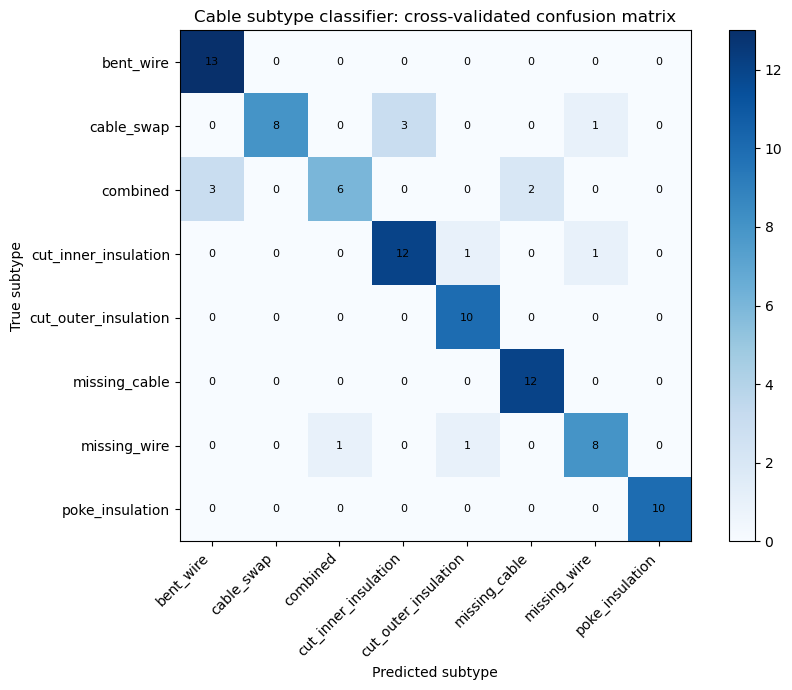

In [3]:
cable_metadata = json.loads(category_model_spec("cable").metadata_path.read_text(encoding="utf-8"))
cable_classifier = cable_metadata["defect_classifier"]
labels = cable_classifier["labels"]
matrix = np.asarray(cable_classifier["confusion_matrix"])

fig, axis = plt.subplots(figsize=(9, 7))
image = axis.imshow(matrix, cmap="Blues")
axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
axis.set_yticks(range(len(labels)), labels)
axis.set_xlabel("Predicted subtype")
axis.set_ylabel("True subtype")
axis.set_title("Cable subtype classifier: cross-validated confusion matrix")
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        axis.text(column, row, int(matrix[row, column]), ha="center", va="center", fontsize=8)
plt.colorbar(image, ax=axis, fraction=0.046)
plt.tight_layout()
plt.show()

,category,expected_subtype,predicted_subtype,confidence,classifier_engine,top_probabilities
0,cable,bent_wire,bent_wire,0.4133,portable_forest,"bent_wire: 0.413, cut_inner_insulation: 0.153,..."
1,capsule,crack,crack,0.9922,fine_tuned_resnet18_onnx,"crack: 0.992, scratch: 0.004, poke: 0.003"
2,bottle,broken_large,broken_large,0.9967,scikit_learn_bundle,"broken_large: 0.997, contamination: 0.003, bro..."
3,wood,color,color,0.9944,fine_tuned_resnet18_onnx,"color: 0.994, combined: 0.003, hole: 0.002"


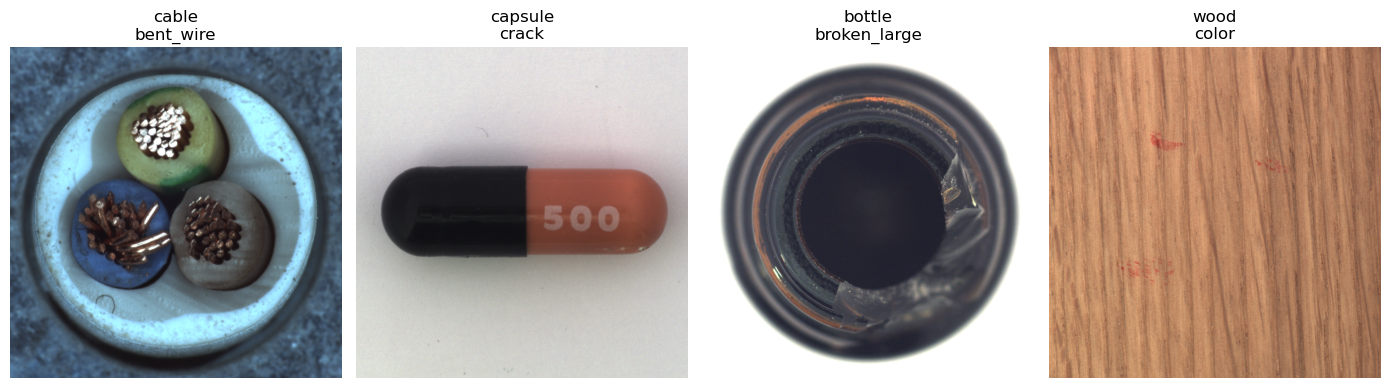

In [4]:
from ml.defect_classifier import classify_defect_type

live_rows = []
live_images = []
for category in ("cable", "capsule", "bottle", "wood"):
    label, path = first_defect(category)
    gt_path = mask_path_for(category, label, path)
    gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE) > 0 if gt_path else None
    spec = category_model_spec(category)
    result = classify_defect_type(
        path,
        spec.classifier_path,
        defect_mask=gt_mask,
        cnn_classifier_path=spec.cnn_classifier_path,
        compact_classifier_path=spec.compact_classifier_path,
    )
    top_probabilities = sorted(result["class_probabilities"].items(), key=lambda item: item[1], reverse=True)[:3]
    live_rows.append(
        {
            "category": category,
            "expected_subtype": label,
            "predicted_subtype": result["defect_type"],
            "confidence": result["confidence"],
            "classifier_engine": result.get("classifier_engine", "scikit_learn_bundle"),
            "top_probabilities": ", ".join(f"{name}: {value:.3f}" for name, value in top_probabilities),
        }
    )
    live_images.append((category, label, path))

display(pd.DataFrame(live_rows))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for axis, (category, label, path) in zip(axes, live_images, strict=True):
    axis.imshow(read_rgb(path))
    axis.set_title(f"{category}\n{label}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## Interpreting confidence correctly

- **Detection confidence** measures certainty that an anomaly exists.
- **Classification confidence** is the probability assigned to the chosen defect subtype.
- The severity calculation intentionally uses detection confidence because severity should not become artificially high merely because a subtype classifier is confident about an uncertain anomaly.

## What this demonstrates

- Good/Defective detection and defect naming are separate tasks with separate metrics.
- Every MVTec category has its own subtype vocabulary and classifier artifact.
- The runtime supports portable scikit-learn, compact forest, and ONNX CNN classifiers through one interface.
- `unknown_defect` is a controlled conflict/fallback state, not a trained MVTec subtype.